<a href="https://colab.research.google.com/github/SidhantPuntambekar/BMI702_Final_Project/blob/main/baseline_developability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:

df = pd.read_csv("GDPa1_v1.2_20250814.csv")
df

,antibody_id,antibody_name,Titer,Purity,SEC %Monomer,SMAC,HIC,HAC,PR_CHO,PR_Ova,...,hc_protein_sequence,hc_dna_sequence,vl_protein_sequence,lc_protein_sequence,lc_dna_sequence,hierarchical_cluster_fold,random_fold,hierarchical_cluster_IgG_isotype_stratified_fold,light_aligned_aho,heavy_aligned_aho
0,GDPa1-001,abagovomab,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,0.263108,...,MRAWIFFLLCLAGRALAQVKLQESGAELARPGASVKLSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,2,2,DIELTQSPASLSASVGETVTITCQAS--ENIY------SYLAWHQQ...,QVKLQES-GAELARPGASVKLSCKASG-YTFTN-----YWMQWVKQ...
1,GDPa1-002,abituzumab,193.31,99.825,97.620,2.745,2.545,3.690,0.205246,0.100155,...,MRAWIFFLLCLAGRALAQVQLQQSGGELAKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,4,0,DIQMTQSPSSLSASVGDRVTITCRAS--QDIS------NYLAWYQQ...,QVQLQQS-GGELAKPGASVKVSCKASG-YTFSS-----FWMHWVRQ...
2,GDPa1-003,abrezekimab,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,0.101180,...,MRAWIFFLLCLAGRALAQVTLKESGPVLVKPTETLTLTCTVSGFSL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,2,2,2,DIQMTQSPSSLSASVGDRVTITCLAS--EDIS------NYLAWYQQ...,QVTLKES-GPVLVKPTETLTLTCTVSG-FSLTN-----YHVQWIRQ...
3,GDPa1-004,abrilumab,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,0.054971,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKVSGYTL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSVSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,3,0,DIQMTQSPSSVSASVGDRVTITCRAS--QGIS------SWLAWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKVSG-YTLSD-----LSIHWVRQ...
4,GDPa1-005,adalimumab,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,0.085628,...,MRAWIFFLLCLAGRALAEVQLVESGGGLVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,2,0,DIQMTQSPSSLSASVGDRVTITCRAS--QGIR------NYLAWYQQ...,EVQLVES-GGGLVQPGRSLRLSCAASG-FTFDD-----YAMHWVRQ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,GDPa1-242,visilizumab,303.51,94.700,98.110,2.745,2.495,4.270,0.337537,0.338022,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCSASSSVSYMNWYQQKPGKAPKRL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCSASSSV...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,1,0,DIQMTQSPSSLSASVGDRVTITCSAS--SSVS-------YMNWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKASG-YTFIS-----YTMHWVRQ...
242,GDPa1-243,xentuzumab,281.21,98.970,99.875,10.000,4.500,NaN,0.178788,0.117684,...,MRAWIFFLLCLAGRALAQVELVESGGGLVQPGGSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIVLTQPPSVSGAPGQRVTISCSGSSSNIGSNSVSWYQQLPGTAPK...,MRAWIFFLLCLAGRALADIVLTQPPSVSGAPGQRVTISCSGSSSNI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,4,4,4,DIVLTQP-PSVSGAPGQRVTISCSGSS-SNIGS-----NSVSWYQQ...,QVELVES-GGGLVQPGGSLRLSCAASG-FTFTS-----YWMSWVRQ...
243,GDPa1-244,zalutumumab,266.55,89.430,98.065,2.705,2.590,3.760,0.000000,0.018385,...,MRAWIFFLLCLAGRALAQVQLVESGGGVVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,AIQLTQSPSSLSASVGDRVTITCRASQDISSALVWYQQKPGKAPKL...,MRAWIFFLLCLAGRALAAIQLTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,0,0,AIQLTQSPSSLSASVGDRVTITCRAS--QDIS------SALVWYQQ...,QVQLVES-GGGVVQPGRSLRLSCAASG-FTFST-----YGMHWVRQ...
244,GDPa1-245,zanolimumab,301.96,99.115,97.780,2.725,2.660,3.730,0.400486,0.100804,...,MRAWI

Antibody isotypes can strongly influence some of the developability metrics, so they must be included as a feature in the model.

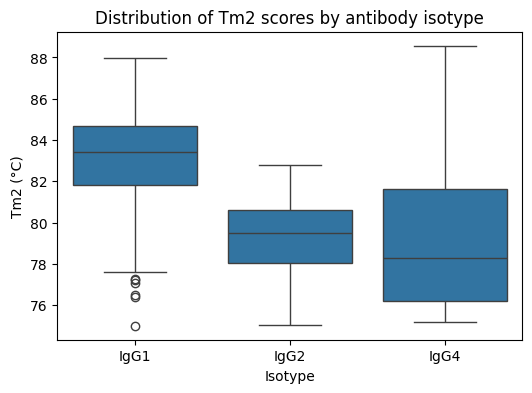

In [3]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = "Tm2")
plt.title("Distribution of Tm2 scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Tm2 (°C)")
plt.show()

In [4]:
targets = ["Titer", "Purity", "SEC %Monomer", "SMAC", "HIC", "HAC", "PR_CHO", "PR_Ova", "Tm2", "AC-SINS_pH7.4"]

print("Missing values per target:")
print(df[targets].isna().sum())

df_full = df.copy()


Missing values per target:
Titer              7
Purity             4
SEC %Monomer       4
SMAC               4
HIC                4
HAC              152
PR_CHO            49
PR_Ova            49
Tm2               53
AC-SINS_pH7.4      4
dtype: int64


In [5]:
# Using p-IgGen as the baseline protein language model to fit ridge regression model
model_name = "ollieturnbull/p-IgGen"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Paired sequence handling: Concatenate heavy and light chains and add beginning ("1") and end ("2") tokens
# (e.g. ["EVQLV...", "DIQMT..."] -> "1E V Q L V ... D I Q M T ... 2")
sequences = [
    "1" + " ".join(heavy) + " ".join(light) + "2"
    for heavy, light in zip(
        df_full["vh_protein_sequence"],
        df_full["vl_protein_sequence"],
    )
]

print(sequences[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/719 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

1Q V K L Q E S G A E L A R P G A S V K L S C K A S G Y T F T N Y W M Q W V K Q R P G Q G L D W I G A I Y P G D G N T R Y T H K F K G K A T L T A D K S S S T A Y M Q L S S L A S E D S G V Y Y C A R G E G N Y A W F A Y W G Q G T T V T V S SD I E L T Q S P A S L S A S V G E T V T I T C Q A S E N I Y S Y L A W H Q Q K Q G K S P Q L L V Y N A K T L A G G V S S R F S G S G S G T H F S L K I K S L Q P E D F G I Y Y C Q H H Y G I L P T F G G G T K L E I K2


In [6]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

batch_size = 16
mean_pooled_embeddings = []

for i in tqdm(range(0, len(sequences), batch_size)):
    batch = tokenizer(sequences[i:i+batch_size], return_tensors="pt", padding=True, truncation=True)
    outputs = model(batch["input_ids"].to(device), return_rep_layers=[-1], output_hidden_states=True)
    embeddings = outputs["hidden_states"][-1].detach().cpu().numpy()
    mean_pooled_embeddings.append(embeddings.mean(axis=1))

mean_pooled_embeddings = np.concatenate(mean_pooled_embeddings)
print(f"Embeddings shape: {mean_pooled_embeddings.shape}")


model.safetensors:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (246, 768)


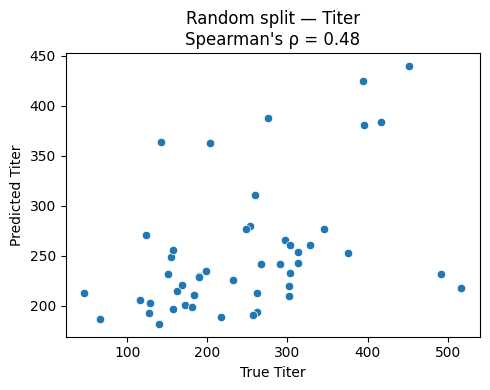

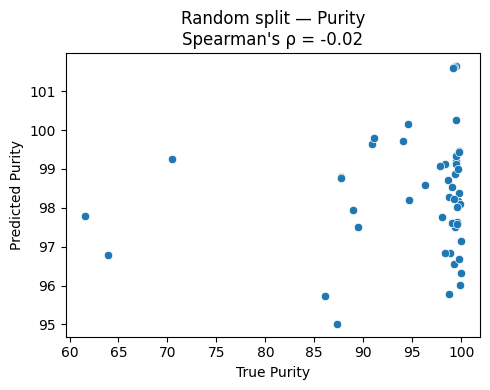

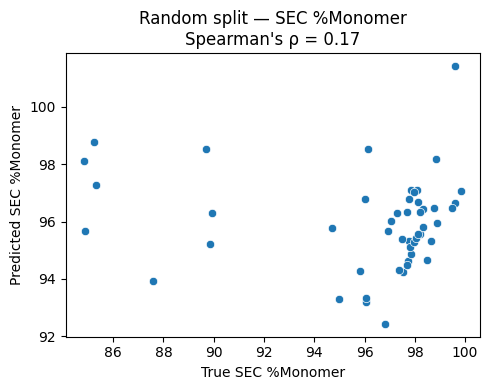

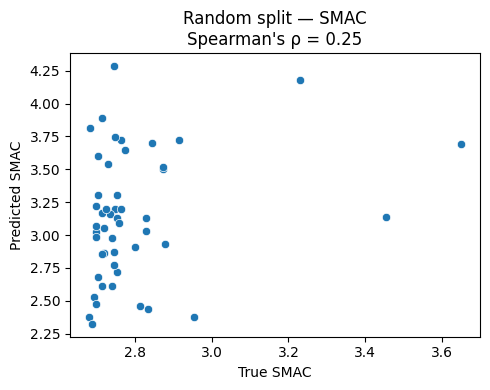

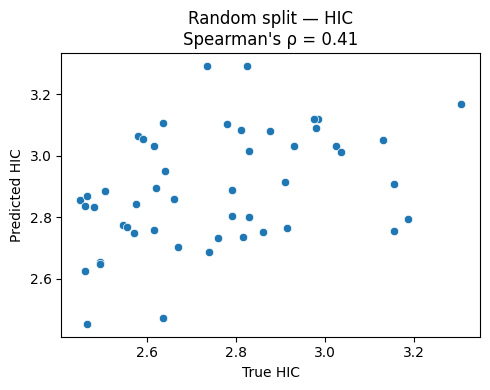

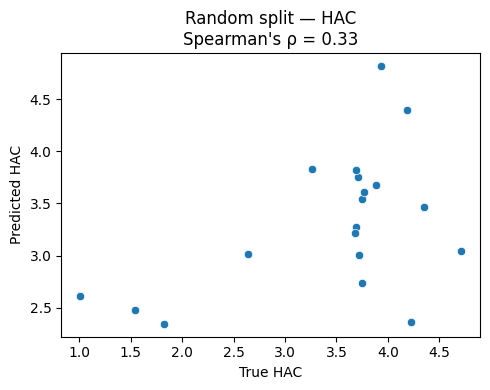

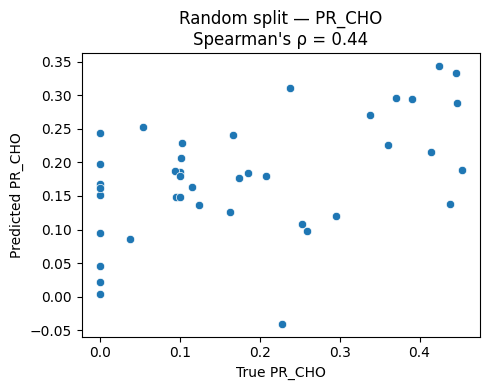

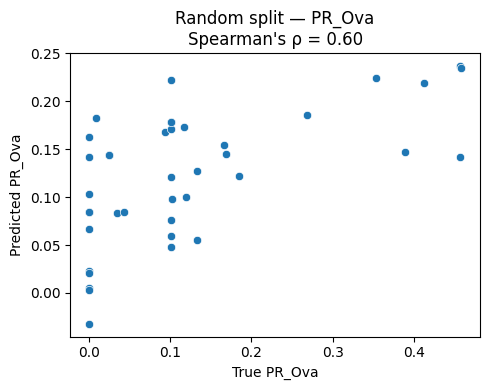

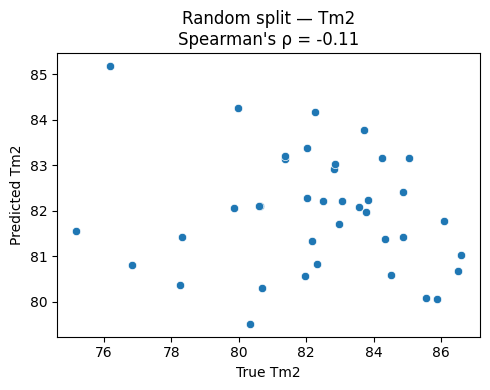

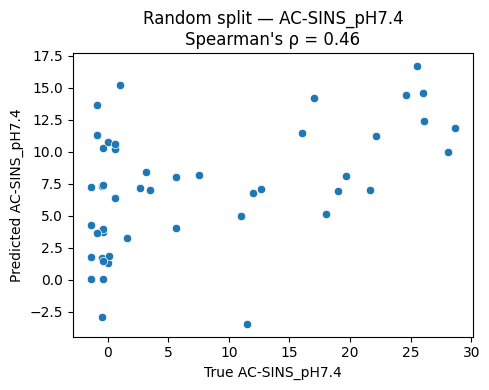


Random-split Spearman ρ summary:
  Titer                 0.4774
  Purity                -0.0187
  SEC %Monomer          0.1736
  SMAC                  0.2503
  HIC                   0.4079
  HAC                   0.3292
  PR_CHO                0.4381
  PR_Ova                0.5983
  Tm2                   -0.1111
  AC-SINS_pH7.4         0.4563


In [7]:
random_split_results = {}

for target in targets:
    mask = df_full[target].notna().values
    X_t = mean_pooled_embeddings[mask]
    y_t = df_full.loc[mask, target].values

    if len(y_t) < 10:          # skip if too few samples
        random_split_results[target] = float("nan")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42
    )

    lm = Ridge()
    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)

    rho = spearmanr(y_pred, y_test).statistic
    random_split_results[target] = rho

    # Scatter plot
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.title(f"Random split — {target}\nSpearman's ρ = {rho:.2f}")
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.tight_layout()
    plt.show()

print("\nRandom-split Spearman ρ summary:")
for t, r in random_split_results.items():
    print(f"  {t:<20s}  {r:.4f}" if not np.isnan(r) else f"  {t:<20s}  N/A")



── Titer ──
Fold	N	Spearman_rho
0	53	0.0123
1	48	0.2505
2	47	0.2832
3	44	0.1682
4	47	0.4922
Overall (all folds)	239	0.2389


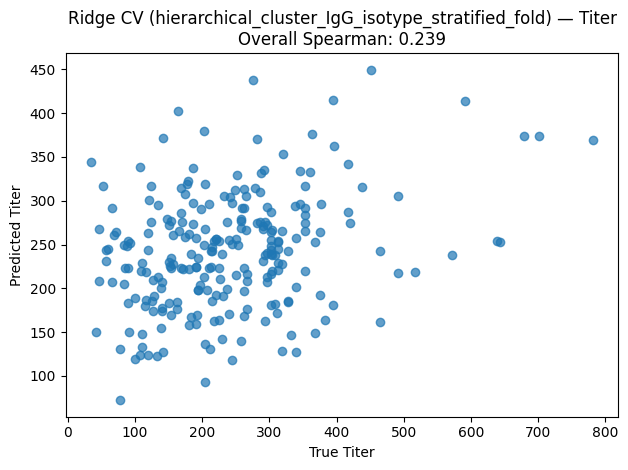


── Purity ──
Fold	N	Spearman_rho
0	53	0.2382
1	48	0.0648
2	48	0.2155
3	44	0.2613
4	49	0.3350
Overall (all folds)	242	0.1802


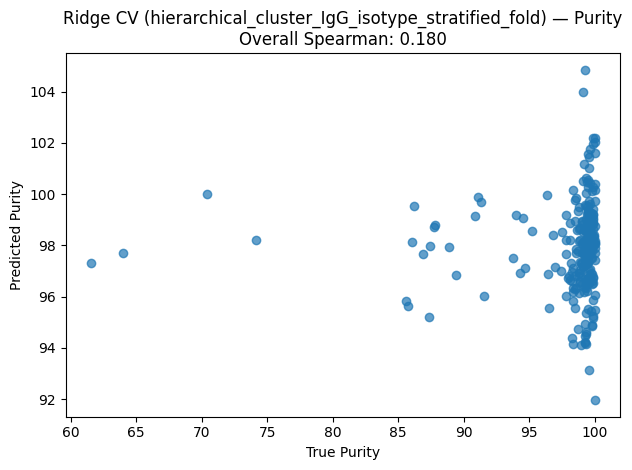


── SEC %Monomer ──
Fold	N	Spearman_rho
0	53	-0.1729
1	48	-0.3883
2	48	-0.3668
3	44	-0.0335
4	49	0.2212
Overall (all folds)	242	-0.1006


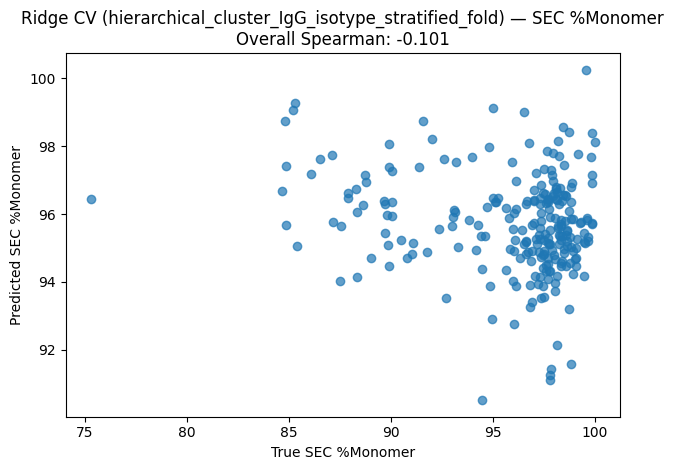


── SMAC ──
Fold	N	Spearman_rho
0	53	0.0877
1	48	0.1396
2	48	0.2093
3	44	0.3242
4	49	0.3624
Overall (all folds)	242	0.2068


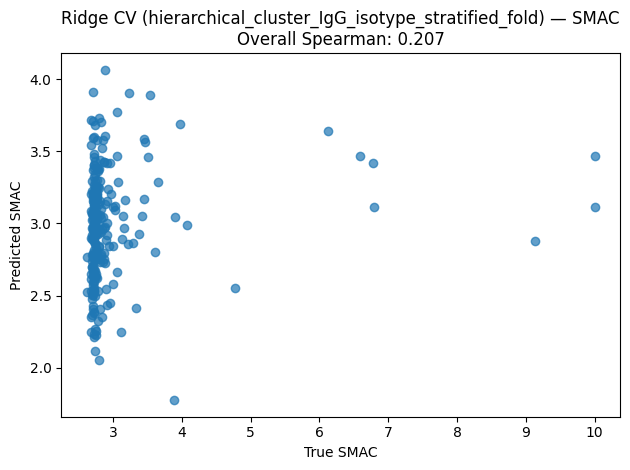


── HIC ──
Fold	N	Spearman_rho
0	53	0.0909
1	48	0.3156
2	48	0.4973
3	44	0.4395
4	49	0.3889
Overall (all folds)	242	0.3352


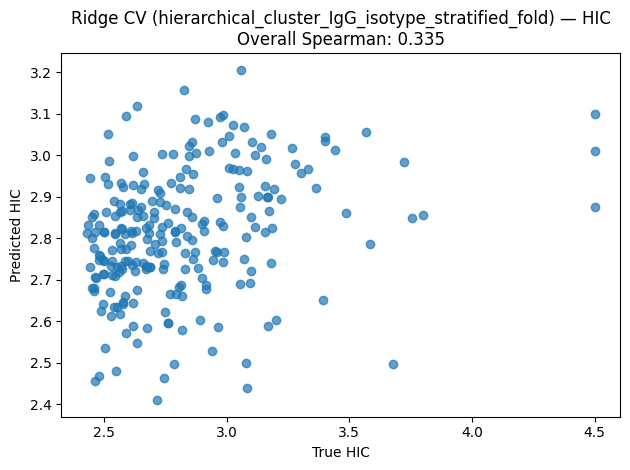


── HAC ──
Fold	N	Spearman_rho
0	20	0.8883
1	19	0.3098
2	18	0.8638
3	16	0.6784
4	21	0.4948
Overall (all folds)	94	0.6206


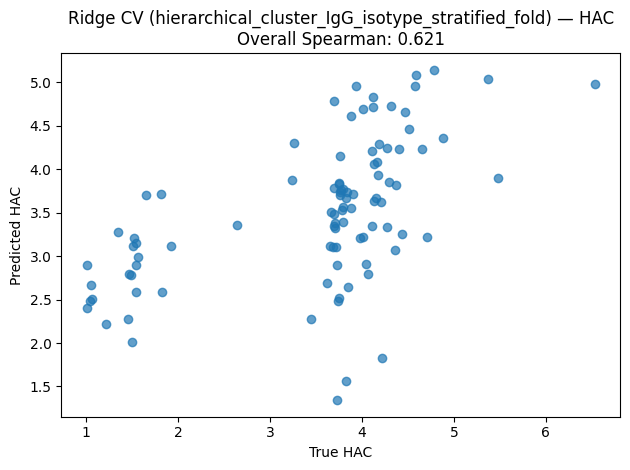


── PR_CHO ──
Fold	N	Spearman_rho
0	45	0.4114
1	40	0.4929
2	36	0.4990
3	35	0.4077
4	41	0.2897
Overall (all folds)	197	0.4956


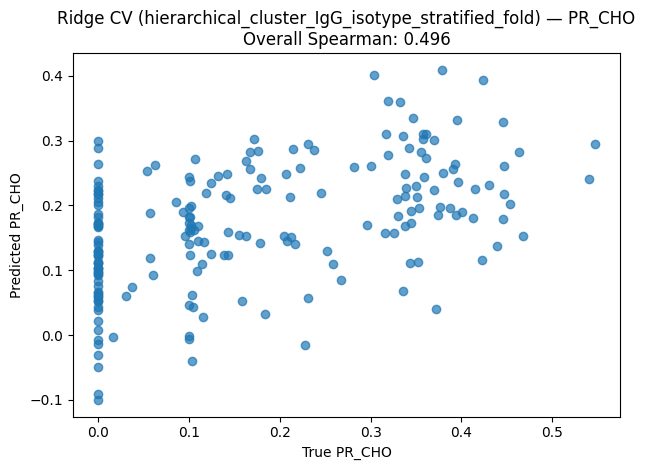


── PR_Ova ──
Fold	N	Spearman_rho
0	45	0.5687
1	40	0.3809
2	36	0.5886
3	35	0.5004
4	41	0.4705
Overall (all folds)	197	0.5488


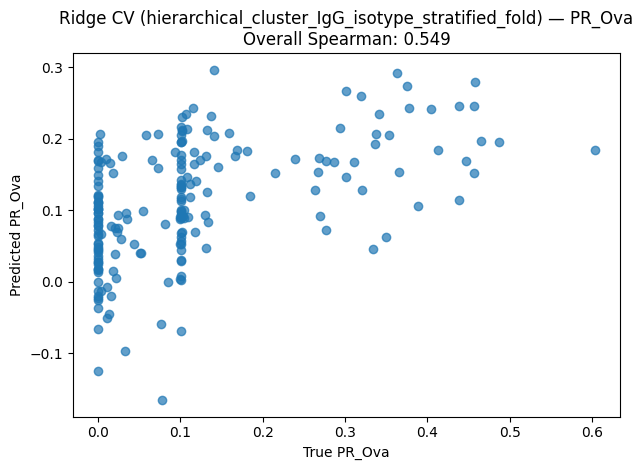


── Tm2 ──
Fold	N	Spearman_rho
0	41	-0.1286
1	38	-0.2402
2	37	-0.1342
3	37	-0.0432
4	40	0.0304
Overall (all folds)	193	-0.0836


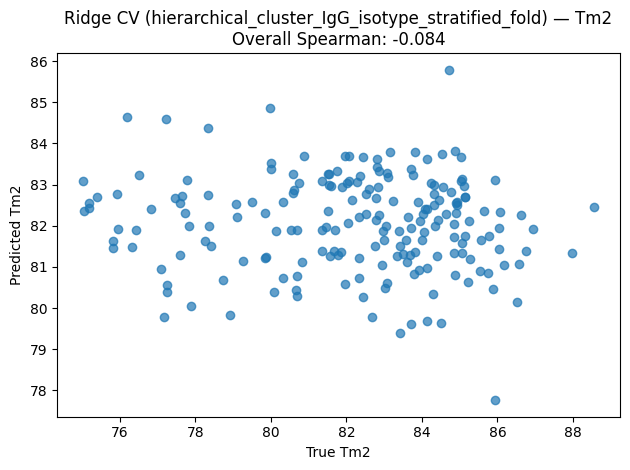


── AC-SINS_pH7.4 ──
Fold	N	Spearman_rho
0	53	0.5465
1	48	0.0089
2	48	0.3459
3	44	0.5894
4	49	0.4860
Overall (all folds)	242	0.3941


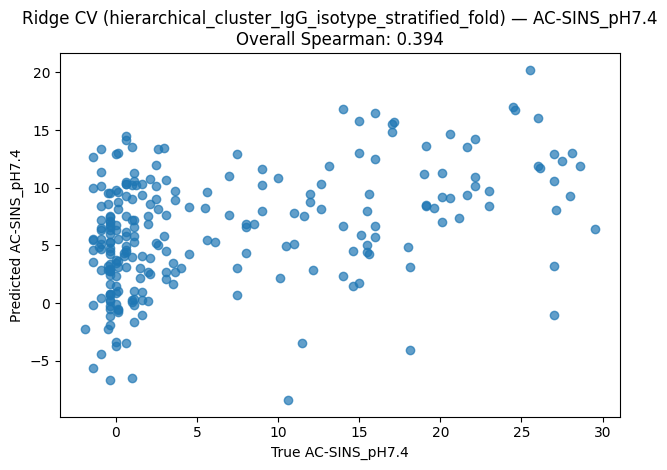

In [8]:
fold_col = "hierarchical_cluster_IgG_isotype_stratified_fold"
cv_results = {}

for target in targets:
    mask = df_full[target].notna().values
    X_t    = mean_pooled_embeddings[mask]
    y_t    = df_full.loc[mask, target].to_numpy(dtype=float)
    folds_t = df_full.loc[mask, fold_col].to_numpy()

    if len(y_t) < 10:
        cv_results[target] = float("nan")
        continue

    unique_folds = [f for f in np.unique(folds_t) if f == f]  # drop NaN

    per_fold_stats = []
    y_pred_all = np.full(len(y_t), np.nan)
    y_true_all = np.full(len(y_t), np.nan)

    for f in unique_folds:
        test_idx  = np.where(folds_t == f)[0]
        train_idx = np.where(folds_t != f)[0]

        X_train, y_train = X_t[train_idx], y_t[train_idx]
        X_test,  y_test  = X_t[test_idx],  y_t[test_idx]

        lm = Ridge()
        lm.fit(X_train, y_train)
        y_pred = lm.predict(X_test)

        y_pred_all[test_idx] = y_pred
        y_true_all[test_idx] = y_test

        rho = spearmanr(y_test, y_pred).statistic
        per_fold_stats.append((int(f), rho, len(y_test)))

    valid = ~np.isnan(y_true_all)
    overall_rho = spearmanr(y_true_all[valid], y_pred_all[valid]).statistic
    cv_results[target] = overall_rho

    print(f"\n── {target} ──")
    print("Fold\tN\tSpearman_rho")
    for f, rho, n in per_fold_stats:
        print(f"{f}\t{n}\t{rho:.4f}")
    print(f"Overall (all folds)\t{valid.sum()}\t{overall_rho:.4f}")

    plt.figure()
    plt.scatter(y_true_all[valid], y_pred_all[valid], alpha=0.7)
    plt.title(f"Ridge CV ({fold_col}) — {target}\nOverall Spearman: {overall_rho:.3f}")
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.tight_layout()
    plt.show()


In [9]:
summary = pd.DataFrame({
    "Target": list(targets),
    "Random-split Spearman ρ": [random_split_results.get(t, float("nan")) for t in targets],
    "CV Spearman ρ": [cv_results.get(t, float("nan")) for t in targets],
})
summary = summary.round(4)
print(summary.to_string(index=False))
summary


       Target  Random-split Spearman ρ  CV Spearman ρ
        Titer                   0.4774         0.2389
       Purity                  -0.0187         0.1802
 SEC %Monomer                   0.1736        -0.1006
         SMAC                   0.2503         0.2068
          HIC                   0.4079         0.3352
          HAC                   0.3292         0.6206
       PR_CHO                   0.4381         0.4956
       PR_Ova                   0.5983         0.5488
          Tm2                  -0.1111        -0.0836
AC-SINS_pH7.4                   0.4563         0.3941


,Target,Random-split Spearman ρ,CV Spearman ρ
0,Titer,0.4774,0.2389
1,Purity,-0.0187,0.1802
2,SEC %Monomer,0.1736,-0.1006
3,SMAC,0.2503,0.2068
4,HIC,0.4079,0.3352
5,HAC,0.3292,0.6206
6,PR_CHO,0.4381,0.4956
7,PR_Ova,0.5983,0.5488
8,Tm2,-0.1111,-0.0836
9,AC-SINS_pH7.4,0.4563,0.3941
